In [7]:
import numpy as np
import pandas as pd
import textwrap
from plotnine import (
    ggplot, aes, theme_set, theme_bw, theme,
    element_blank, element_text,
)

This is a notebook that translates my wellbeing oecd paper analysis into python. I do this to learn python proberly using pandas and scikit learn.

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

SEED = 4595
DATA = Path("data/processed_data")

new_sample = pd.read_parquet(DATA / "data.parquet").iloc[:, 1:]


def theme_plots():
    return theme_bw() + theme(
        panel_border=element_blank(),
        text=element_text(size=14, color="#1A1A1A", lineheight=1.1),
    )

# optional: apply to every plot in the session, like ggplot2::theme_set()
theme_set(theme_plots())

Defining the Variable selection function using random forest. This was taken from some github repository.

In [18]:
?RandomForestRegressor

In [2]:
def var_sel_ranger(
    data: pd.DataFrame,
    dependent_variable_name: str,
    frac: float = 0.2,
    min_vars: int = 1,
    random_state: int = SEED,
    **rf_kwargs,
):
    """Recursive feature elimination via RF impurity importance, scored on OOB error."""
    if not isinstance(data, pd.DataFrame):
        raise TypeError("'data' must be a DataFrame.")
    if not 0 < frac < 1:
        raise ValueError("'frac' must be greater than 0 and less than 1.")

    y = data[dependent_variable_name].to_numpy()
    varz = [c for c in data.columns if c != dependent_variable_name]

    params = dict(
        n_estimators=500,
        max_features=1 / 3,      # ranger regression default: floor(p/3)
        min_samples_leaf=5,      # ranger regression default: min.node.size = 5
        oob_score=True,
        bootstrap=True,
        n_jobs=-1,
    )
    params.update(rf_kwargs)

    selected_vars, errors = [], []

    while len(varz) >= min_vars:
        X = data[varz].to_numpy()

        fit = RandomForestRegressor(random_state=random_state, **params).fit(X, y)

        selected_vars.append(list(varz))
        errors.append(mean_squared_error(y, fit.oob_prediction_))

        order = np.argsort(fit.feature_importances_)[::-1]
        nsel = int(np.floor(len(varz) * (1 - frac)))
        varz = [varz[i] for i in order[:nsel]]

    return {"selected_vars": selected_vars, "errors": errors}


selectvar = var_sel_ranger(new_sample, "SUBJ_LIFE_SAT")

In [ ]:
selection_data = pd.DataFrame({
    "no_variables": [len(v) for v in selectvar["selected_vars"]],
    "oob": selectvar["errors"],
})

# minimum error
print(selection_data.loc[selection_data["oob"] == selection_data["oob"].min()])

   no_variables       oob
8            21  0.247081
Object `loc` not found.


In [14]:
is_min = selection_data["oob"] == selection_data["oob"].min()
is_chosen = selection_data["no_variables"] == 16

selection_data["label"] = np.select(
    [is_min, is_chosen], ["Minimum", "Our chosen configuration"], default=None
)
selection_data["nudge_y"] = np.select([is_min, is_chosen], [0.15, -0.1], default=np.nan)

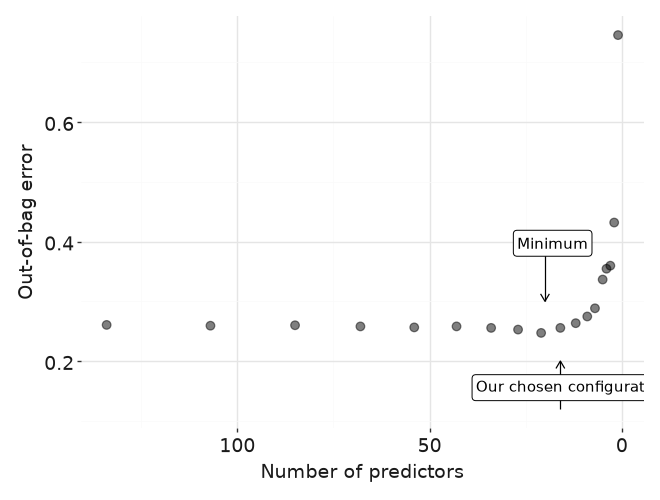

In [15]:
from plotnine import (
    ggplot, aes, geom_point, geom_segment, geom_label, arrow,
    xlab, ylab, scale_x_reverse, ggsave,
)

labels = selection_data.dropna(subset=["label"]).assign(
    y_lab=lambda d: d["oob"] + d["nudge_y"],
    x_lab=lambda d: d["no_variables"] - 3,
)

arrows = pd.DataFrame({"x": [20, 16], "xend": [20, 16],
                       "y": [0.4, 0.12], "yend": [0.3, 0.20]})

p = (
    ggplot(selection_data)
    + geom_point(aes(x="no_variables", y="oob"), size=3, alpha=0.5)
    + geom_segment(aes(x="x", xend="xend", y="y", yend="yend"),
                   data=arrows, arrow=arrow(length=0.1), inherit_aes=False)
    + geom_label(aes(x="x_lab", y="y_lab", label="label"),
                 data=labels, inherit_aes=False)
    + xlab("Number of predictors")
    + ylab("Out-of-bag error")
    + scale_x_reverse()
    + theme_plots()
)
p

#p.save("plots/variable_selection.pdf", width=10 * 0.75, height=7 * 0.75)

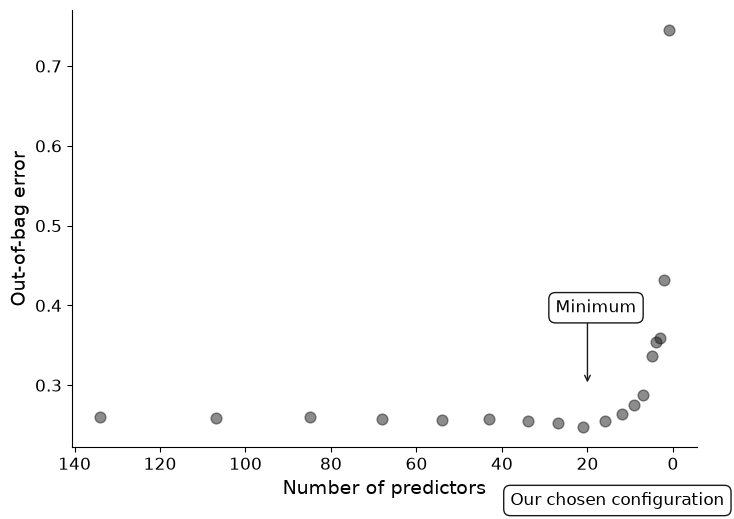

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 5.25))

ax.scatter(selection_data["no_variables"], selection_data["oob"],
           s=60, alpha=0.5, color="#1A1A1A")

ax.annotate("", xy=(20, 0.30), xytext=(20, 0.40),
            arrowprops=dict(arrowstyle="->", color="#1A1A1A"))
ax.annotate("", xy=(16, 0.20), xytext=(16, 0.12),
            arrowprops=dict(arrowstyle="->", color="#1A1A1A"))

for _, row in selection_data.dropna(subset=["label"]).iterrows():
    ax.text(row["no_variables"] - 3, row["oob"] + row["nudge_y"], row["label"],
            ha="center", va="center", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#1A1A1A"))

ax.invert_xaxis()
ax.set_xlabel("Number of predictors", fontsize=14)
ax.set_ylabel("Out-of-bag error", fontsize=14)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=12)

fig.tight_layout()
#fig.savefig("plots/variable_selection.pdf")